# Application of Random Forest Algorithms for the Classification of Molecular Subtypes of Stomach Adenocarcinoma (TCGA-STAD)
## Multiclass vs. Binary Approach
**Luana da Silva do Aido** - Trackmodule 1 <br> Zurich University of Applied Science <br> Department of Applied Computational Life Science <br> January 2026 

## 1. Introduction
Stomach adenocarcinoma is a biologically heterogeneous cancer, meaning that tumours of the same clinical type can differ strongly at the molecular level (Khanna et al., 2013). Previous studies have shown that stomach cancer can be divided into distinct molecular subtypes, which are associated with differences in tumor biology, prognosis, and response to therapy (Cancer Genome Atlas Research Network, 2014). Correctly identifying these subtypes is therefore an important task in cancer research and precision medicine.

Gene expression profiling allows the measurement of thousands of genes simultaneously and provides detailed information about tumour biology (Goldenring & Nam, 2010). Large public projects such as The Cancer Genome Atlas (TCGA) have generated comprehensive gene expression datasets together with molecular subtype labels for stomach adenocarcinoma. However, these datasets are highly dimensional, typically containing expression values for tens of thousands of genes but only a limited number of tumour samples, which makes data analysis challenging.

Machine learning methods are well suited for analysing high-dimensional biological data. In particular, Random Forest classifiers are widely used because they are robust, can model non-linear relationships, and perform well even when the number of features is large (Breiman, 2001). Random Forests also provide measures of feature importance, which can help to identify genes that are relevant for subtype classification (Wijaya, 2023).

The object of the mini project is to classify molecular subtypes of stomach adenocarcinoma using gene expression data from the TCGA-STAD cohort. Gene expression profiles from primary tumor samples are used as input features, while molecular subtype labels serve as the target variable. Feature selection is applied to reduce dimensionality before training a Random Forest classifiert. Model performance is evaluated using standard classification metrics.


## 2. Setup
### 2.1 Import libraries

In [62]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import *
import matplotlib.pyplot as plt
import seaborn as sns

### 2.2 Load the Datasets
Was ist alles im Daten satz enthalten, für was sind die anderen

In [11]:
expression_df = pd.read_csv("/Users/luanadoaido/ZHAW/HS25/Track1/Mini Project/Track/Trackmodule_1_RF_TCGA-STAD/TCGA-STAD_gene_expression_cpm.csv", index_col=0)
print("Data shape Expression:", expression_df.shape)
# 431 rows und 60616 columns

subtype_df = pd.read_csv("/Users/luanadoaido/ZHAW/HS25/Track1/Mini Project/Track/Trackmodule_1_RF_TCGA-STAD/TCGA-STAD_subtypes.csv", index_col=0)
print("Data shape Subtypes:", subtype_df.shape)
# 411 rows und 4 columns


Data shape Expression: (431, 60616)
Data shape Subtypes: (411, 4)


In [12]:
expr_ids = set(expression_df.index)
label_ids = set(subtype_df.index)

print(len(expr_ids))
print(len(label_ids))
print(len(expr_ids & label_ids))  # Schnittmenge
# das heisst wenn es gemerged wird, dann habe ich nur 411 rows


431
411
411


In [13]:
#zusammenführen
cancer_df = pd.merge(subtype_df, expression_df, on="submitter_id", how="inner")
print("Data shape whole DF:", cancer_df.shape)
#411 rows und 60620 Columns
print(cancer_df.head(10))

Data shape whole DF: (411, 60620)
                         barcode_gene_expr Molecular.Subtype MSI_phenotype  \
submitter_id                                                                 
TCGA-3M-AB46  TCGA-3M-AB46-01A-11R-A414-31               NaN           MSS   
TCGA-3M-AB47  TCGA-3M-AB47-01A-22R-A414-31               NaN         MSI-L   
TCGA-B7-5816  TCGA-B7-5816-01A-21R-1602-13               MSI         MSI-H   
TCGA-B7-5818  TCGA-B7-5818-01A-11R-1602-13               EBV         MSI-L   
TCGA-B7-A5TI  TCGA-B7-A5TI-01A-11R-A31P-31               NaN         MSI-H   
TCGA-B7-A5TJ  TCGA-B7-A5TJ-01A-11R-A31P-31               NaN         MSI-H   
TCGA-B7-A5TK  TCGA-B7-A5TK-01A-12R-A36D-31               NaN           MSS   
TCGA-B7-A5TN  TCGA-B7-A5TN-01A-21R-A31P-31               NaN           MSS   
TCGA-BR-4187  TCGA-BR-4187-01A-01R-1131-13                GS           MSS   
TCGA-BR-4191  TCGA-BR-4191-01A-02R-1131-13               CIN           MSS   

                MSI_TMB  ENSG

### 2.3 Data cleaning
Nas und duplicate weg nehmen

In [14]:
cancer_df.info()

print("\n", cancer_df.isna().sum().sum()) #157

print(cancer_df.isna().sum().sort_values(ascending=False).head())
#there are 157 na

print("\n", cancer_df.index.duplicated().sum())
#no duplicated rows
print("\n", cancer_df.columns.duplicated().sum())
#no duplicated columns



<class 'pandas.core.frame.DataFrame'>
Index: 411 entries, TCGA-3M-AB46 to TCGA-ZQ-A9CR
Columns: 60620 entries, barcode_gene_expr to ENSG00000288675
dtypes: float64(60616), object(4)
memory usage: 190.1+ MB

 157
Molecular.Subtype    137
MSI_phenotype         10
MSI_TMB               10
ENSG00000252494        0
ENSG00000252479        0
dtype: int64

 0

 0


In [15]:
#cat variablen rausnehmen, verändern
cancer_df.select_dtypes(include="object").head()
print(cancer_df.columns)


Index(['barcode_gene_expr', 'Molecular.Subtype', 'MSI_phenotype', 'MSI_TMB',
       'ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419',
       'ENSG00000000457', 'ENSG00000000460', 'ENSG00000000938',
       ...
       'ENSG00000288661', 'ENSG00000288662', 'ENSG00000288663',
       'ENSG00000288665', 'ENSG00000288667', 'ENSG00000288669',
       'ENSG00000288670', 'ENSG00000288671', 'ENSG00000288674',
       'ENSG00000288675'],
      dtype='object', length=60620)


In [16]:
#as we have two different approaches we need to make two different Datasets which we need to clean
df_multi = cancer_df.dropna(subset=["Molecular.Subtype"]).copy()

df_binary = cancer_df.dropna(subset=["MSI_phenotype"]).copy()

df_binary["MSI_binary"] = df_binary["MSI_phenotype"].replace({
    "MSI-H": "MSI",
    "MSI-L": "MSI"
})

df_binary["MSI_binary"].value_counts()



MSI_binary
MSS    265
MSI    136
Name: count, dtype: int64

## 3. Exploratory Data Analysis

## 4. Preprocessing
### 4.1 Seperating Features and Lables

In [17]:
#for the multi class approach
y_multi = df_multi["Molecular.Subtype"] #Targe Value
X_multi = df_multi.drop(columns=df_multi.select_dtypes(include="object").columns)

print(X_multi.dtypes.unique())   # nur float


#for the binary class approach
y_binary = df_binary["MSI_binary"] #Targen value 2
X_binary = df_binary.drop(columns=df_binary.select_dtypes(include="object").columns)

print(X_binary.dtypes.unique())

[dtype('float64')]
[dtype('float64')]


### 4.3 Splitting into train/test sets

In [18]:
#for multi class approach
train_X_multi, test_X_multi, train_y_multi, test_y_multi = train_test_split(X_multi, y_multi, train_size= 0.7, random_state=1)

#for binary approach
train_X_binary, test_X_binary, train_y_binary, test_y_binary = train_test_split(X_binary, y_binary, train_size= 0.7, random_state=1)

In [19]:
#Allgemein ob es balanced ist
print("Testing to see if the target value is balanced in the data set:")
print(y_multi.value_counts(), y_multi.value_counts(normalize=True) * 100)


#testing if the target value in the testing and training set is balanced
train_y_multi = pd.Series(train_y_multi)
test_y_multi = pd.Series(test_y_multi)
print("\nTesting to see if the training and test set is balanced (multi):")
print("train:", train_y_multi.value_counts(), train_y_multi.value_counts(normalize=True) * 100)
print("\ntest:", test_y_multi.value_counts(), test_y_multi.value_counts(normalize=True) * 100)


train_y_binary = pd.Series(train_y_binary)
test_y_binary = pd.Series(test_y_binary)
print("\nTesting to see if the training and test set is balanced (binary):")
print("train:", train_y_binary.value_counts(), train_y_binary.value_counts(normalize=True) * 100)
print("\ntest:", test_y_binary.value_counts(), test_y_binary.value_counts(normalize=True) * 100)



Testing to see if the target value is balanced in the data set:
Molecular.Subtype
CIN    136
MSI     59
GS      54
EBV     25
Name: count, dtype: int64 Molecular.Subtype
CIN    49.635036
MSI    21.532847
GS     19.708029
EBV     9.124088
Name: proportion, dtype: float64

Testing to see if the training and test set is balanced (multi):
train: Molecular.Subtype
CIN    99
MSI    39
GS     38
EBV    15
Name: count, dtype: int64 Molecular.Subtype
CIN    51.832461
MSI    20.418848
GS     19.895288
EBV     7.853403
Name: proportion, dtype: float64

test: Molecular.Subtype
CIN    37
MSI    20
GS     16
EBV    10
Name: count, dtype: int64 Molecular.Subtype
CIN    44.578313
MSI    24.096386
GS     19.277108
EBV    12.048193
Name: proportion, dtype: float64

Testing to see if the training and test set is balanced (binary):
train: MSI_binary
MSS    182
MSI     98
Name: count, dtype: int64 MSI_binary
MSS    65.0
MSI    35.0
Name: proportion, dtype: float64

test: MSI_binary
MSS    83
MSI    38
Name

The target distribution in the dataset is not perfectly balanced. However, all classes are sufficiently represented. Moderate class imbalance is common in biological and clinical datasets and does not inherently invalidate supervised learning approaches.

### 4.4 Feature Filtering
Due to the high dimensionality of the gene expression data, a two-step feature filtering strategy was applied. Genes with low expression across samples were removed, followed by variance-based filtering to eliminate non-informative features. 
#### 4.4.1 Low-Expression Filter
CPM threshold to define "expressed" and "unexpressed" 
As a general rule, a good threshold can be chosen for a CPM value that corresponds to a count of 10

low expression darf nur auf Genexpresion angewendet werden
CPM muss grösser als 0 sein und mindestens in den 10% der Samples
https://combine-australia.github.io/RNAseq-R/slides/RNASeq_filtering_qc.pdf


In [25]:
#for Multiclass Target - filter machen
min_samples_multi = int(0.1 *train_X_multi.shape[0])

#das eigentliche
mask_multi = (train_X_multi > 0).sum(axis=0) >= min_samples_multi

#Anwenden
X_train_multi_filt = train_X_multi.loc[:, mask_multi]
X_test_multi_filt = test_X_multi.loc[:, mask_multi]


In [27]:
#for Binary Target - filter machen
min_samples_binary = int(0.1 *train_X_binary.shape[0])

#das eigentliche
mask_binary = (train_X_binary > 0).sum(axis=0) >= min_samples_binary

#Anwenden
X_train_binary_filt = train_X_binary.loc[:, mask_binary]
X_test_binary_filt = test_X_binary.loc[:, mask_binary]

#### 4.4.1 Variance Threshold

In [42]:
vt = VarianceThreshold(threshold=0.01)

X_train_var_multi = vt.fit_transform(X_train_multi_filt)
X_test_var_multi = vt.transform(X_test_multi_filt)


X_train_var_binary = vt.fit_transform(X_train_binary_filt)
X_test_var_binary = vt.transform(X_test_binary_filt)

## 5. Modelling
### 5.1 Multiclass Approach
#### 5.1.1 Train the Random Forest Model

In [43]:
rfc_multi = RandomForestClassifier(n_estimators=101, bootstrap=True, max_depth=70, max_features=20, criterion='gini', random_state=42)
rfc_multi.fit(X_train_var_multi , train_y_multi)

,n_estimators,101
,criterion,'gini'
,max_depth,70
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,20
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 5.2 Binary Approach
#### 5.2.1 Train the Random Forest Model

In [44]:
rfc_binary = RandomForestClassifier(n_estimators=101, bootstrap=True, max_depth=70, max_features=20, criterion='gini', random_state=42)
rfc_binary.fit(X_train_var_binary , train_y_binary)

,n_estimators,101
,criterion,'gini'
,max_depth,70
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,20
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 6. Evaluation of model performance and Results
### 6.1 Multiclass approach
#### 6.1.1 Prediction and calculation

Accuracy of multi class RF: 0.6987951807228916
              precision    recall  f1-score   support

         CIN       0.64      0.92      0.76        37
         EBV       1.00      0.20      0.33        10
          GS       0.67      0.62      0.65        16
         MSI       0.92      0.60      0.73        20

    accuracy                           0.70        83
   macro avg       0.81      0.59      0.62        83
weighted avg       0.76      0.70      0.68        83



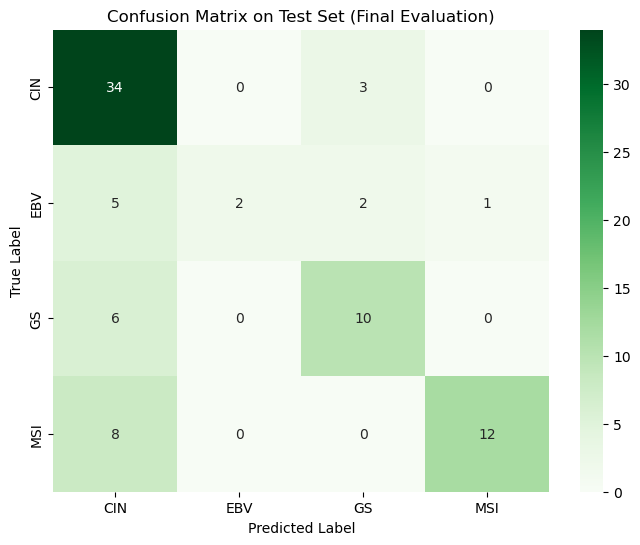

In [61]:
#Predicting
y_pred_multi = rfc_multi.predict(X_test_var_multi)

#metrics
#accuracy score
print("Accuracy of multi class RF:", accuracy_score(test_y_multi, y_pred_multi))
print(classification_report(test_y_multi, y_pred_multi))

#Confusionmatrix:
multi_test = confusion_matrix(test_y_multi, y_pred_multi)

plt.figure(figsize=(8, 6))
sns.heatmap(multi_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=rfc_multi.classes_,
            yticklabels=rfc_multi.classes_)
plt.title('Confusion Matrix on Test Set (Final Evaluation)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [65]:
str(X_test_var_multi)

'[[1.62539117e+02 0.00000000e+00 7.26521529e+01 ... 3.92014231e+00\n  2.24501542e-01 3.62656337e-01]\n [1.10108387e+02 3.05450838e-01 5.36663842e+01 ... 6.95896692e+00\n  1.72646126e-01 4.64816493e-01]\n [3.45709672e+01 2.88813427e-02 2.69174114e+01 ... 1.32854176e+00\n  2.31050742e-01 3.46576112e-01]\n ...\n [2.35680090e+01 0.00000000e+00 4.53463618e+01 ... 1.73924345e+00\n  2.52064268e-01 1.76444987e-01]\n [1.83781276e+01 3.36595743e-02 3.45852126e+01 ... 7.72487229e+00\n  1.85127658e-01 5.04893614e-01]\n [7.91133407e+01 2.80344935e-02 5.27048478e+01 ... 2.52310442e+00\n  8.41034806e-02 5.60689871e-02]]'

#### 6.1.2 Feature importance

In [64]:
# Feature Importance

import_multi = rfc_multi.feature_importances_
features = X_test_var_multi.columns

fea_imp = pd.DataFrame({
    "features": features,
    "importance": import_multi
}).sort_values("importance", ascending=False)


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

### 6.2 Binary approach
#### 6.2.1 Prediction and calculation

Accuracy of multi class RF: 0.7603305785123967
              precision    recall  f1-score   support

         MSI       0.74      0.37      0.49        38
         MSS       0.76      0.94      0.84        83

    accuracy                           0.76       121
   macro avg       0.75      0.65      0.67       121
weighted avg       0.76      0.76      0.73       121



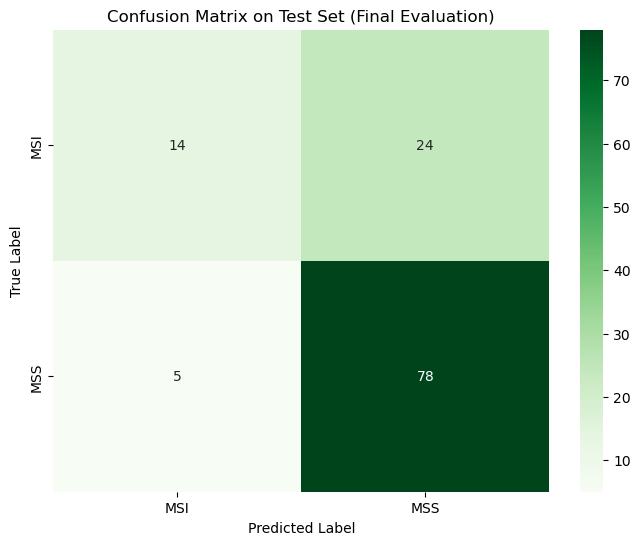

In [60]:
#Predicting
y_pred_binary = rfc_binary.predict(X_test_var_binary)

#metrics
#accuracy score
print("Accuracy of multi class RF:", accuracy_score(test_y_binary, y_pred_binary))
print(classification_report(test_y_binary, y_pred_binary))

#Confusionmatrix:
binary_test = confusion_matrix(test_y_binary, y_pred_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(binary_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=rfc_binary.classes_,
            yticklabels=rfc_binary.classes_)


plt.title('Confusion Matrix on Test Set (Final Evaluation)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


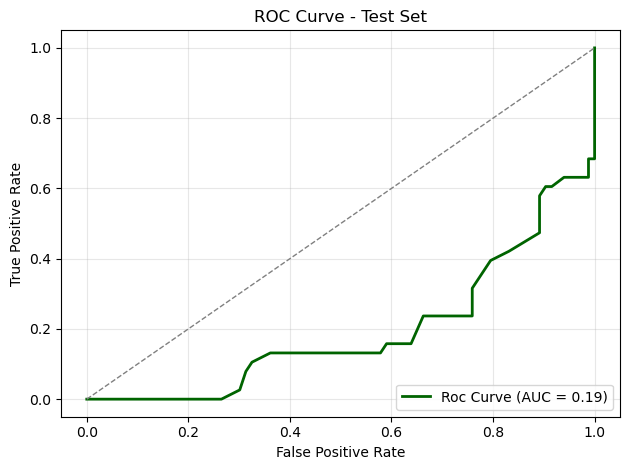

In [ ]:
#ROC-AUC
#predict probabilities for MSS
test_prob_binary = rfc_binary.predict_proba(X_test_var_binary)[:,1] #for posiive variable MSI
fpr_binary, tpr_binary, thresholds = roc_curve(test_y_binary, test_prob_binary, pos_label="MSI")
roc_auc_binary = auc(fpr_binary,tpr_binary)
print("ROC-AUC Value:", roc_auc_binary)
#Roc curve visualization:

plt.Figure(figsize=(8,6))
plt.plot(fpr_binary,tpr_binary, color ="darkgreen", lw = 2,
         label=f"Roc Curve (AUC = {roc_auc_binary:.2f})")

plt.plot([0,1],[0,1], color = "gray", lw= 1, linestyle = "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Test Set")
plt.legend(loc = "lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2.2 Feature importance

## 7. Discussion

## References

Baladram, S. (2024, November 30). Random Forest, Explained: A Visual Guide with Code Examples. TDS Archive. https://medium.com/data-science/random-forest-explained-a-visual-guide-with-code-examples-9f736a6e1b3c

Breiman, L. (2001). Random Forests. Machine Learning, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324

Cancer Genome Atlas Research Network. (2014). Comprehensive molecular characterization of gastric adenocarcinoma. Nature, 513(7517), 202–209. https://doi.org/10.1038/nature13480

Goldenring, J. R., & Nam, K. T. (2010). Oxyntic Atrophy, Metaplasia, and Gastric Cancer. In Progress in Molecular Biology and Translational Science (Vol. 96, pp. 117–131). Academic Press. https://doi.org/10.1016/B978-0-12-381280-3.00005-1

Khanna, C., Avery, A. C., Olver, C., & Paoloni, M. C. (2013). Molecular Diagnostics. In Withrow and MacEwen’s Small Animal Clinical Oncology (pp. 131–142). W.B. Saunders. https://doi.org/10.1016/B978-1-4377-2362-5.00008-6

Mohamadi, Z., Shafizadeh, A., Aliyan, Y., Shayesteh, S. F., Goudarzi, P., Khodabandeh, A., Vaghari, A., Ashrafi, H., Bahrami, O., ZarinKhat, A., Khodabandeh, Y., & Pouyan, K. (2025). The application of random forest-based models in prognostication of gastrointestinal tract malignancies: A systematic review. Frontiers in Artificial Intelligence, 8. https://doi.org/10.3389/frai.2025.1517670

Wijaya, C. Y. (2023, December 16). Random Forest Feature Importance Explained. https://www.nb-data.com/p/random-forest-feature-importance





## Use of AI
AI tools were used for code debugging and for improving English grammar and clarity. All an- alytical decisions, interpretations, and conclusions were made independently by the author.